# Customer Churn Prediction – Data Cleaning & EDA

## Objective

The objective of this notebook is to clean the raw customer churn
dataset and perform Exploratory Data Analysis (EDA).

## Data Cleaning

The cleaning process will include:

- Handling blank values
- Correcting numerical data types
- Checking duplicate records
- Validating categorical values
- Validating numerical ranges
- Removing columns that should not be used as predictive features

## Exploratory Data Analysis

The analysis will investigate:

- Customer churn distribution
- Customer demographics
- Tenure
- Contract type
- Internet services
- Payment methods
- Monthly charges
- Total charges
- Relationships between customer characteristics and churn

## Important

All cleaning decisions will be based on the data-quality investigation
performed in the previous notebook.

## 1. Import Libraries

The required Python libraries are imported for data manipulation,
numerical analysis, visualization, and statistical exploration.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Raw Dataset

The original raw dataset is loaded again.

The raw file is not modified directly. All cleaning operations will
be performed on a copy of the DataFrame.

In [2]:
data_path = "../data/raw/telco_customer_churn.csv"

df = pd.read_csv(data_path)

df_clean = df.copy()

print("Raw dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Raw dataset shape: (7043, 21)
Working dataset shape: (7043, 21)


## 3. Standardize Blank Values

Blank strings and whitespace-only values are converted into proper
missing values (`NaN`) so that they can be handled consistently during
data cleaning.

In [3]:
df_clean = df_clean.replace(r"^\s*$", np.nan, regex=True)

## 4. Convert TotalCharges to Numerical Format

`TotalCharges` represents the cumulative amount charged to each
customer.

The column is converted from text representation to numerical format
so that it can be used correctly in statistical analysis and machine
learning.

In [4]:
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

In [5]:
df_clean["TotalCharges"].dtype

dtype('float64')

In [6]:
missing_after_cleaning = df_clean.isnull().sum()

missing_after_cleaning[missing_after_cleaning > 0]

TotalCharges    11
dtype: int64

## 5. Investigate Remaining Missing Values

The data-cleaning process identified 11 missing values in `TotalCharges`.

Before deciding how to handle these records, we inspect the affected
customers and their related attributes.

This prevents us from removing valid customer records without
understanding why the values are missing.

In [7]:
missing_total_charges = df_clean[df_clean["TotalCharges"].isnull()]

missing_total_charges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
missing_total_charges[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [9]:
missing_total_charges["tenure"].value_counts()

tenure
0    11
Name: count, dtype: int64

In [10]:
missing_total_charges["MonthlyCharges"]

488     52.55
753     20.25
936     80.85
1082    25.75
1340    56.05
3331    19.85
3826    25.35
4380    20.00
5218    19.70
6670    73.35
6754    61.90
Name: MonthlyCharges, dtype: float64

## 6. Handle Missing TotalCharges

The investigation identified 11 records with missing `TotalCharges`.

All 11 records have a tenure of 0 months. Since `TotalCharges`
represents cumulative charges and these customers have no recorded
tenure, the missing cumulative charge is treated as 0.

The customer records are retained rather than removed.

In [11]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [12]:
df_clean["TotalCharges"].isnull().sum()

np.int64(0)

In [13]:
df_clean.loc[
    missing_total_charges.index,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


In [14]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
remaining_missing = df_clean.isnull().sum()

remaining_missing[remaining_missing > 0]

Series([], dtype: int64)

## 7. Duplicate Record Validation

Duplicate records are checked again after the initial cleaning
operations to confirm that the working dataset does not contain
identical rows.

In [17]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [18]:
duplicate_customer_ids = df_clean["customerID"].duplicated().sum()

print("Duplicate customer IDs:", duplicate_customer_ids)

Duplicate customer IDs: 0


## 8. Save Cleaned Dataset

The cleaned dataset is saved separately from the raw dataset.

The original raw CSV is preserved so that the complete data-processing
workflow remains reproducible.

In [19]:
processed_path = "../data/processed/telco_customer_churn_cleaned.csv"

df_clean.to_csv(processed_path, index=False)

print("Cleaned dataset saved successfully.")
print("Path:", processed_path)

Cleaned dataset saved successfully.
Path: ../data/processed/telco_customer_churn_cleaned.csv


In [20]:
df_clean.shape

(7043, 21)

In [21]:
pd.read_csv(processed_path).shape

(7043, 21)

In [22]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
df_clean.duplicated().sum()

np.int64(0)

In [24]:
df_clean["customerID"].duplicated().sum()

np.int64(0)

In [25]:
df_clean.shape

(7043, 21)

In [26]:
pd.read_csv(processed_path).shape

(7043, 21)

# Exploratory Data Analysis

After cleaning the dataset, we analyze customer characteristics,
service usage, contracts, billing behavior, and their relationship
with customer churn.

The objective is to identify meaningful patterns that can later
support feature engineering and predictive modeling.

In [27]:
processed_path = "../data/processed/telco_customer_churn_cleaned.csv"

df = pd.read_csv(processed_path)

print("Cleaned dataset loaded successfully.")

Cleaned dataset loaded successfully.


In [28]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df.shape

(7043, 21)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 1. Overall Churn Distribution

Understanding the distribution of the target variable is important
before developing a classification model.

We compare customers who churned with customers who remained with
the company.

In [31]:
churn_counts = df["Churn"].value_counts()

churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [32]:
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

churn_percentages.round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

## 2. Churn Count Visualization

A count plot is used to visually compare the number of customers
who churned with those who remained.

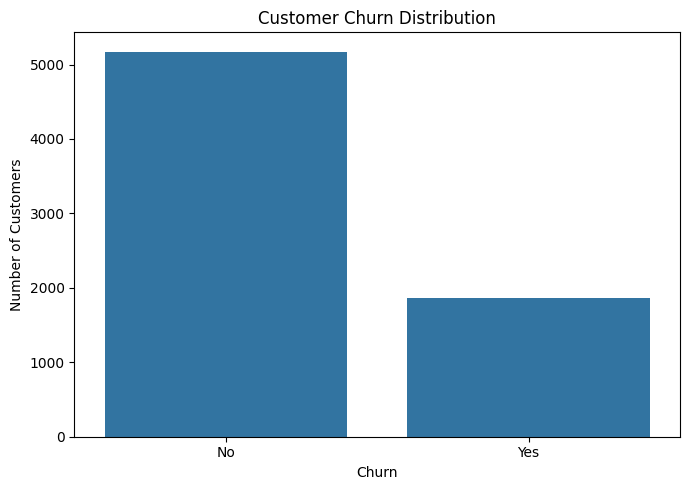

In [34]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

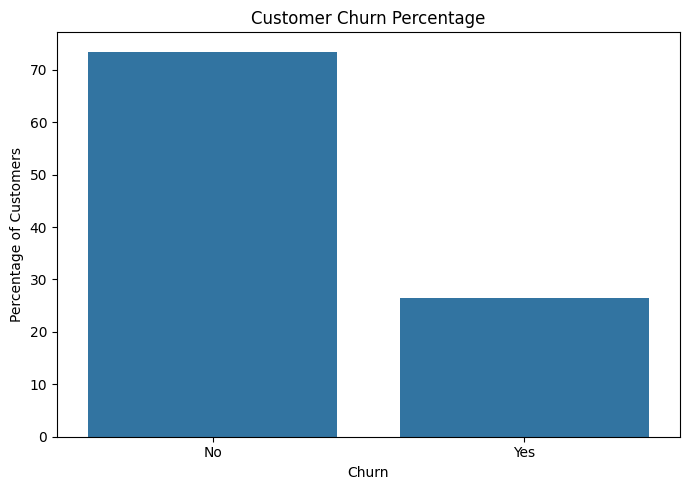

In [35]:
churn_pct = df["Churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_pct.index,
    y=churn_pct.values
)

plt.title("Customer Churn Percentage")
plt.xlabel("Churn")
plt.ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()

## 3. Churn by Contract Type

Contract duration may influence customer retention.

We compare churn rates across different contract types to determine
whether customers with different contractual commitments exhibit
different churn behavior.

In [36]:
contract_churn = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


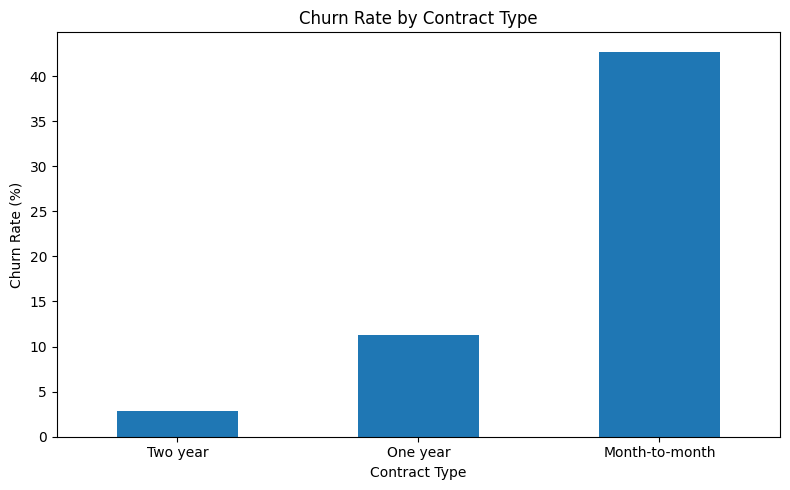

In [37]:
contract_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Churn by Tenure

Tenure represents the number of months a customer has remained with
the company.

We examine whether churn behavior changes as customer tenure increases.

In [38]:
tenure_bins = [-1, 12, 24, 48, 60, np.inf]

tenure_labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-60 months",
    "60+ months"
]

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

In [39]:
tenure_churn = (
    pd.crosstab(
        df["tenure_group"],
        df["Churn"],
        normalize="index"
    ) * 100
)

tenure_churn

Churn,No,Yes
tenure_group,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-60 months,85.576923,14.423077
60+ months,93.390192,6.609808


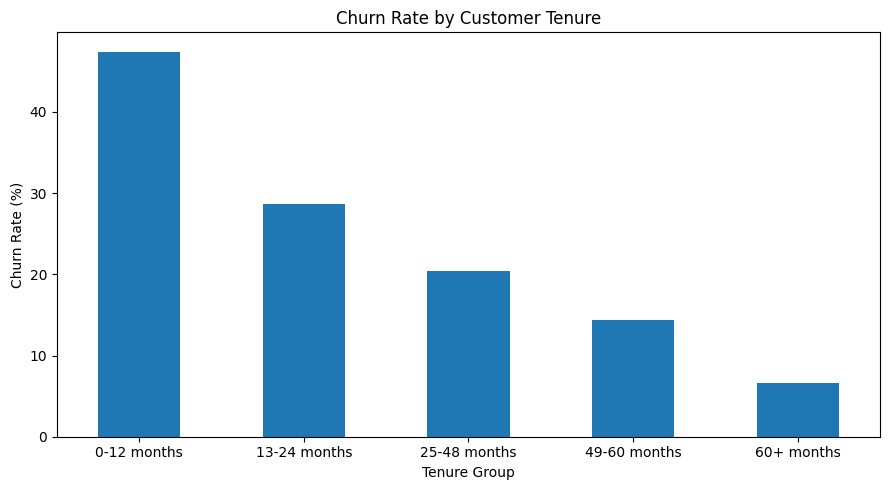

In [40]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Monthly Charges and Churn

Monthly charges represent the recurring amount paid by customers.

We compare the distribution of monthly charges between customers who
churned and customers who remained.

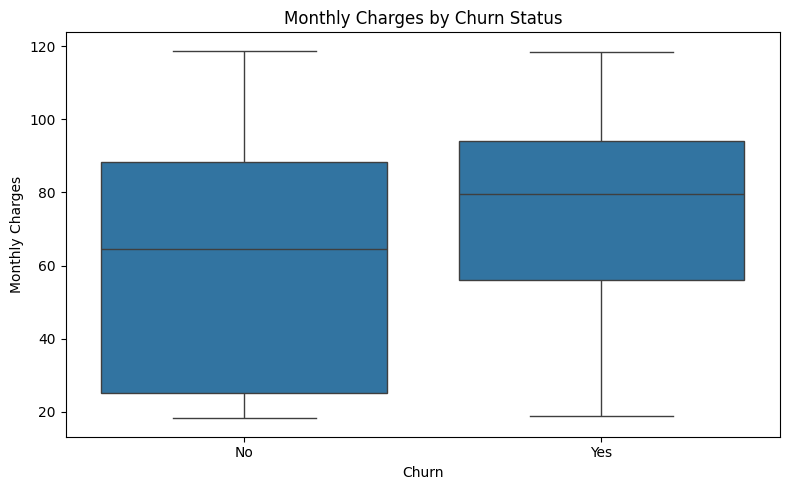

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

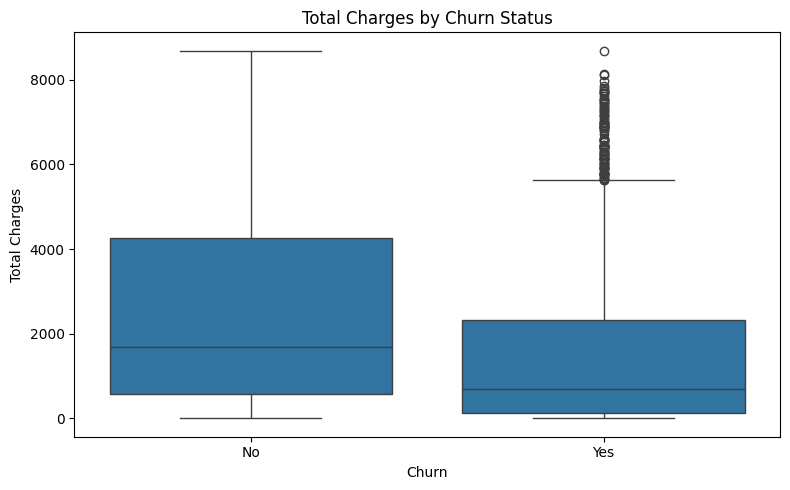

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

In [43]:
internet_churn = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


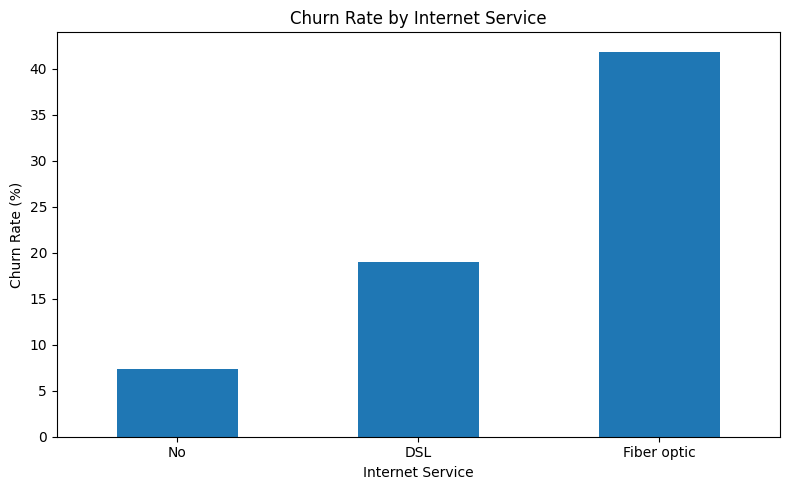

In [44]:
internet_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
payment_churn = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    ) * 100
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


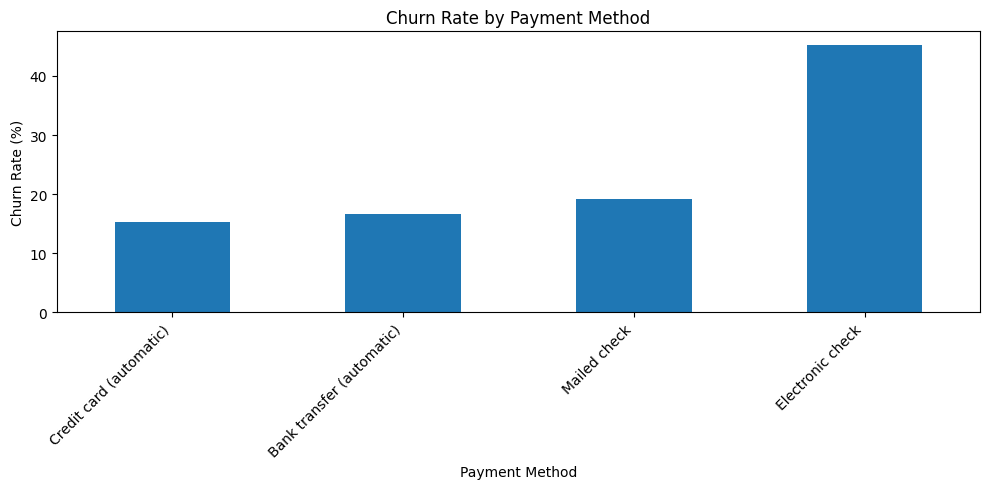

In [46]:
payment_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [47]:
senior_churn = (
    pd.crosstab(
        df["SeniorCitizen"],
        df["Churn"],
        normalize="index"
    ) * 100
)

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


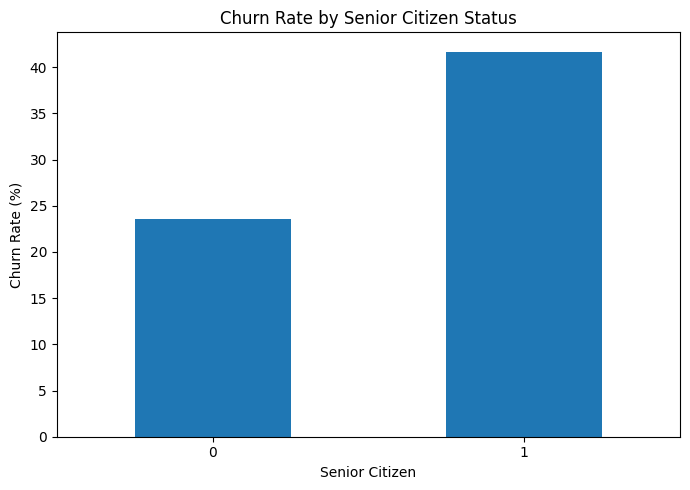

In [48]:
senior_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
tech_support_churn = (
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    ) * 100
)

tech_support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


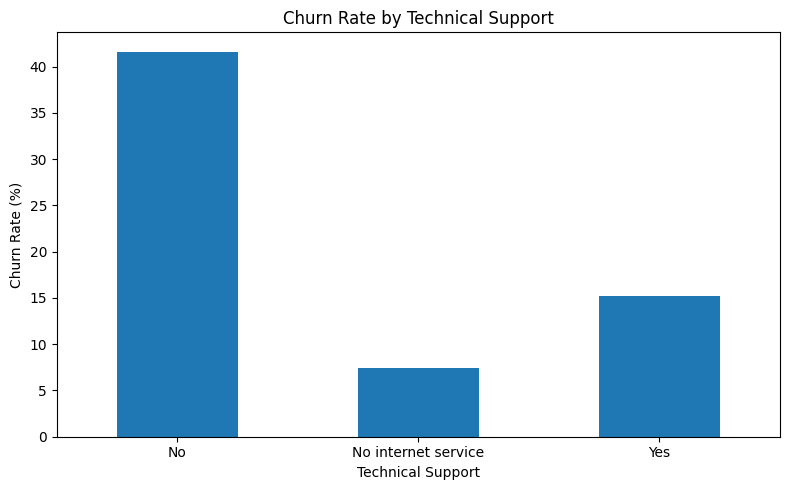

In [50]:
tech_support_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()